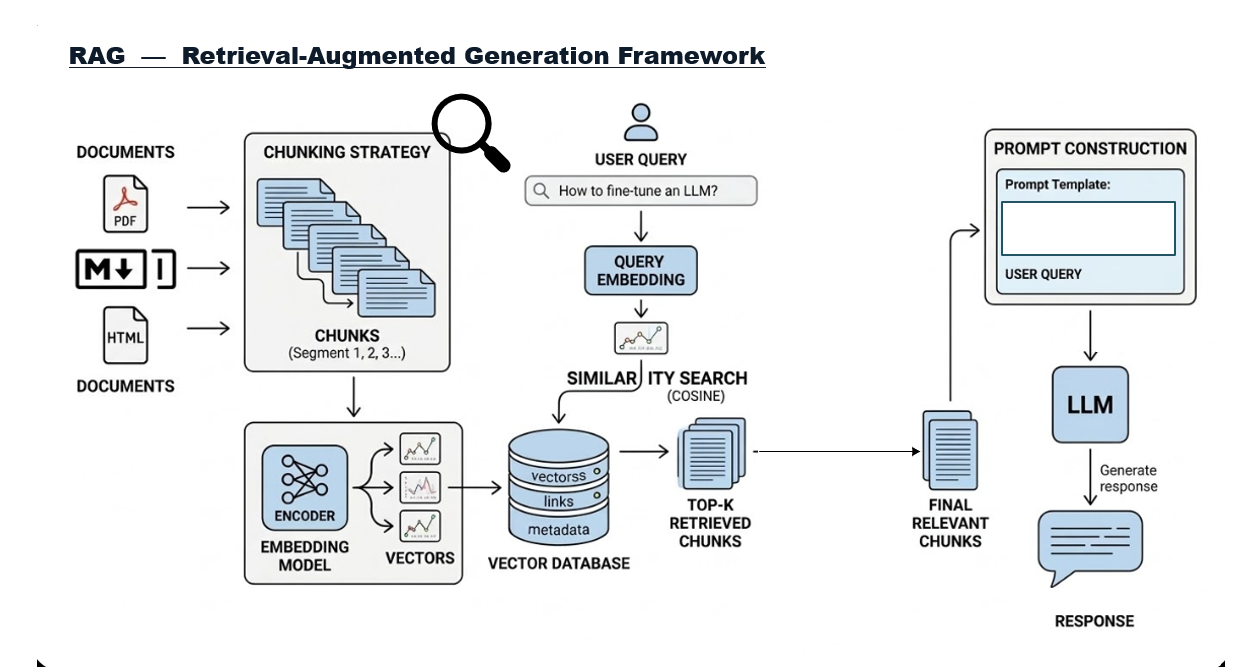

# Chat with PDF using RAG - Hands-On
## Powered by HuggingFace 🤗

---

## Welcome!

In this Hands on, you'll build a system that can **answer questions from the famous 'Attention Is All You Need' paper** — the paper that introduced the Transformer, the backbone of ChatGPT and modern AI.

### What you'll build:
A chatbot that:
- Reads the PDF
- Understands the content using embeddings
- Answers your questions about it — **completely free, no API keys!**

### What is RAG?
**RAG** = **R**etrieval-**A**ugmented **G**eneration

> Think of it as giving an AI a textbook to reference *before* answering. Instead of guessing from memory, it finds the relevant pages first, then answers.

---

##  Agenda

| Part | Topic |
|------|-------|
| part 0 | Setup — Install libraries, load PDF |
| Part 1 | Load & Chunk PDFs |
| Part 2 | Embeddings + Vector Database |
| Part 3 | Retrieval Pipeline |
| Part 4 | Chat with PDF using LangChain |

Let's go!

---
# Part 0: Setup (15 minutes)

## Install Required Libraries

Everything we use today is **completely free and open-source**.
No credit card. No API key. No sign-up required.

| Library | Purpose |
|---------|----------|
| `langchain` | Framework that connects all the pieces |
| `pypdf` | Reads PDF files |
| `chromadb` | Vector database to store & search embeddings |
| `sentence-transformers` | Free embedding models from HuggingFace |
| `transformers` | Free language models from HuggingFace |
| `torch` | Deep learning backend |


In [1]:
!pip install -q langchain-huggingface
!pip install -q langchain-core
!pip install -q langchain-community
!pip install -q pypdf chromadb
!pip install -q sentence-transformers
!pip install -q transformers torch
!pip install -q accelerate

print("All libraries installed!")

All libraries installed!


## Load the PDF

We're using the **'Attention Is All You Need'** paper (Vaswani et al., 2017).
This is one of the most important papers in AI history — it introduced the **Transformer** architecture.

Make sure the PDF file is in the **same folder as this notebook**.
The file should be named: `NIPS-2017-attention-is-all-you-need-Paper.pdf`

In [3]:
pwd # if not make sure you change the present working directory to the notebook folder

'/Users/gauravmapari/COEP/lecture12'

In [4]:
import os

# Path to our PDF
PDF_PATH = "NIPS-2017-attention-is-all-you-need-Paper.pdf"

# Check the file exists
if os.path.exists(PDF_PATH):
    size_kb = os.path.getsize(PDF_PATH) / 1024
    print(f"PDF found: {PDF_PATH}")
    print(f"File size: {size_kb:.1f} KB")
else:
    print(f"File not found: {PDF_PATH}")
    print("   Please make sure the PDF is in the same folder as this notebook.")

PDF found: NIPS-2017-attention-is-all-you-need-Paper.pdf
File size: 2163.3 KB


In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

---
# Part 1: Load and Chunk PDFs

## Goal
Understand how do we split PDFs into smaller pieces.


## Step 1.1: Load the PDF

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
# TODO: find more ways to load PDF, 
# what can be the real life challenges? -
# How to handle documents other than PDFs?

# Load the PDF — PyPDFLoader reads it page by page
print(f"Loading: {PDF_PATH}")
loader = PyPDFLoader(PDF_PATH)
documents = loader.load()

print(f"\nLoaded successfully!")
print(f"Total pages: {len(documents)}")
print(f"\n{'─'*55}")
print("Preview of Page 1 (first 400 characters):")
print(f"{'─'*55}")
print(documents[0].page_content[:400])
print(f"{'─'*55}")

Loading: NIPS-2017-attention-is-all-you-need-Paper.pdf

Loaded successfully!
Total pages: 15

───────────────────────────────────────────────────────
Preview of Page 1 (first 400 characters):
───────────────────────────────────────────────────────
Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
G
───────────────────────────────────────────────────────


In [7]:
documents[1].page_content

'1 Introduction\nRecurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks\nin particular, have been firmly established as state of the art approaches in sequence modeling and\ntransduction problems such as language modeling and machine translation [ 35, 2, 5]. Numerous\nefforts have since continued to push the boundaries of recurrent language models and encoder-decoder\narchitectures [38, 24, 15].\nRecurrent models typically factor computation along the symbol positions of the input and output\nsequences. Aligning the positions to steps in computation time, they generate a sequence of hidden\nstates ht, as a function of the previous hidden state ht−1 and the input for position t. This inherently\nsequential nature precludes parallelization within training examples, which becomes critical at longer\nsequence lengths, as memory constraints limit batching across examples. Recent work has achieved\nsignificant improvements in computational efficiency t

### Understanding the Output

When LangChain loads a PDF, each page becomes a **Document object** with two parts:
- `page_content` → the actual text from that page
- `metadata` → information *about* the page (page number, source file, etc.)

The metadata is important! Later we can tell users: *"This answer came from page 4 of the paper."*

In [8]:
# Let's explore metadata
print("Metadata of the first page:")
print(documents[0].metadata)

print(f"\nMetadata of the last page:")
print(documents[-1].metadata)

print(f"\nTotal characters across all pages: {sum(len(d.page_content) for d in documents):,}")

Metadata of the first page:
{'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'NIPS-2017-attention-is-all-you-need-Paper.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}

Metadata of the last page:
{'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'NIPS-2017-attention-is-all-you-need-Paper.pdf', 'total_pages': 15, 'page': 14, 'page_label': '15'}

Total characters across all pages: 39,615


## Step 1.2: Split Pages into Chunks

### Two important parameters:

```
─────────────────────────────────────────────────
│         CHUNK 1 (1000 chars)                  │
│                               ┌───────────────┤
│                               │  OVERLAP      │
└───────────────────────────────┤  (200 chars)  │
                                │               │
                                │  CHUNK 2      │
                                │  (1000 chars) │
                                └───────────────┘
```

- **chunk_size = 1000** → Each chunk is ~1000 characters (~half a page)
- **chunk_overlap = 200** → 200 characters are shared between consecutive chunks

> **Why overlap?** Without it, a sentence split between two chunks loses context. Overlap ensures ideas that span chunk boundaries are still captured.

In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Create the text splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,     # Each chunk: ~1000 characters
    chunk_overlap=200,   # 200 characters shared between neighbors
    length_function=len, # How to measure length (count characters)
    separators=["\n\n", "\n", " ", ""]  # Try to split at paragraph → line → word → character
)

# Split!
chunks = text_splitter.split_documents(documents)

print(f"Pages loaded:   {len(documents)}")
print(f"Chunks created: {len(chunks)}")
print(f"Avg chunk size: {sum(len(c.page_content) for c in chunks)//len(chunks)} characters")

print(f"\n{'─'*55}")
print("Sample chunk (chunk #5):")
print(f"{'─'*55}")
print(chunks[5].page_content)
print(f"{'─'*55}")
print(f"From: Page {chunks[5].metadata.get('page', '?')} of the paper")

Pages loaded:   15
Chunks created: 52
Avg chunk size: 873 characters

───────────────────────────────────────────────────────
Sample chunk (chunk #5):
───────────────────────────────────────────────────────
sequential nature precludes parallelization within training examples, which becomes critical at longer
sequence lengths, as memory constraints limit batching across examples. Recent work has achieved
significant improvements in computational efficiency through factorization tricks [21] and conditional
computation [32], while also improving model performance in case of the latter. The fundamental
constraint of sequential computation, however, remains.
Attention mechanisms have become an integral part of compelling sequence modeling and transduc-
tion models in various tasks, allowing modeling of dependencies without regard to their distance in
the input or output sequences [2, 19]. In all but a few cases [27], however, such attention mechanisms
are used in conjunction with a recurren

## Exercise 1: Experiment with Chunk Size
Change `chunk_size` below and observe the effect on the number of chunks.

| chunk_size | Expected chunks |
|------------|----------------|
| 500 | More (smaller pieces) |
| 1000 | Medium |
| 2000 | Fewer (bigger pieces) |

In [10]:
# EXERCISE: Try different chunk sizes!

for size in [500, 1000, 1500, 2000]:
    splitter = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=200)
    test_chunks = splitter.split_documents(documents)
    print(f"chunk_size={size:5d}  →  {len(test_chunks):3d} chunks")

print("\n💡 Observation: Smaller chunks = more chunks (more precise but less context)")
print("               Larger chunks = fewer chunks (more context but harder to search precisely)")

chunk_size=  500  →  131 chunks
chunk_size= 1000  →   52 chunks
chunk_size= 1500  →   38 chunks
chunk_size= 2000  →   27 chunks

💡 Observation: Smaller chunks = more chunks (more precise but less context)
               Larger chunks = fewer chunks (more context but harder to search precisely)


### Key Takeaways — Part 1

- PDFs are loaded **page by page** into Document objects
- We split pages into **smaller chunks** for efficient searching
- **chunk_size** controls how big each piece is
- **chunk_overlap** prevents losing context at boundaries
- For most use cases, **1000 characters with 200 overlap** is a good starting point

---

# Part 2: Embeddings + Vector Database

## Goal
Convert text chunks into numbers (embeddings) and store them in a searchable database.

## What Are Embeddings?

Computers don't understand words — they only understand numbers.
**Embeddings** convert text into lists of numbers that capture *meaning*.


```
"attention mechanism"      → [0.23, 0.87, 0.11, ...]  (384 numbers)
"self-attention in models" → [0.21, 0.85, 0.14, ...]  ← SIMILAR! (close together)
"recipe for pasta"         → [0.91, 0.03, 0.76, ...]  ← DIFFERENT! (far apart)
```

Similar *meaning* → Similar *numbers* → Easy to find related content!

## Step 2.1: Load the Embedding Model

We'll use `all-MiniLM-L6-v2` from HuggingFace — a free, fast, and highly effective model.

| Property | Value |
|----------|-------|
| Model size | ~90 MB |
| Embedding dimensions | 384 numbers per sentence |
| Cost | Free |
| Runs on | Your local machine (no internet needed after download) |

In [12]:
from langchain_community.embeddings import HuggingFaceEmbeddings

print("🔄 Loading embedding model from HuggingFace...")
print("   (First time: downloads ~90MB. Subsequent runs: instant from cache)\n")

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    # model_kwargs={'device': 'cuda'},   # Use CPU (works on any machine)
    encode_kwargs={'normalize_embeddings': True}  # Normalize for cosine similarity
)

print("✅ Embedding model loaded!")
print("   Model: all-MiniLM-L6-v2")
print("   This model converts any text into 384 numbers that capture its meaning.")

🔄 Loading embedding model from HuggingFace...
   (First time: downloads ~90MB. Subsequent runs: instant from cache)



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedding model loaded!
   Model: all-MiniLM-L6-v2
   This model converts any text into 384 numbers that capture its meaning.


### Let's See an Embedding!

In [13]:
# Embed a sentence from the paper
test_sentence = "Attention is all you need for sequence transduction."

embedding_vector = embeddings.embed_query(test_sentence)

print(f"Original text:")
print(f"  '{test_sentence}'")
print(f"\nEmbedding (the computer's understanding):")
print(f"  Length: {len(embedding_vector)} numbers")
print(f"  First 8 values: {[round(x, 4) for x in embedding_vector[:8]]}")
print(f"  ...and {len(embedding_vector)-8} more numbers")
print(f"\nThese {len(embedding_vector)} numbers are the 'fingerprint' of that sentence!")

Original text:
  'Attention is all you need for sequence transduction.'

Embedding (the computer's understanding):
  Length: 384 numbers
  First 8 values: [-0.0427, -0.0474, 0.0063, -0.0182, 0.029, 0.0655, -0.017, 0.0198]
  ...and 376 more numbers

These 384 numbers are the 'fingerprint' of that sentence!


## Step 2.2: Prove That Similar Sentences Have Similar Embeddings

We'll use **cosine similarity** to measure how close two embeddings are.

| Score | Meaning |
|-------|--------|
| ~1.0 | Almost identical meaning |
| ~0.7 | Very related |
| ~0.3 | Somewhat related |
| ~0.0 | Completely different |

In [14]:
import numpy as np

def cosine_similarity(a, b):
    """Measure similarity between two embeddings. Returns 0 (different) to 1 (identical)."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Three test sentences
s1 = "The Transformer uses multi-head self-attention mechanisms."
s2 = "Self-attention allows the model to look at other positions."
s3 = "The best recipe for chocolate cake needs three eggs."

# Get embeddings
e1 = embeddings.embed_query(s1)
e2 = embeddings.embed_query(s2)
e3 = embeddings.embed_query(s3)

sim_12 = cosine_similarity(e1, e2)
sim_13 = cosine_similarity(e1, e3)

print("Sentence 1:", s1)
print("Sentence 2:", s2)
print("Sentence 3:", s3)
print()
print(f"Similarity Results:")
print(f"  Sentence 1 vs 2 (both about attention): {sim_12:.3f}  HIGH")
print(f"  Sentence 1 vs 3 (AI vs cooking):        {sim_13:.3f}  LOW")
print()
print("**** The model 'knows' that sentences 1 & 2 are related!******")

Sentence 1: The Transformer uses multi-head self-attention mechanisms.
Sentence 2: Self-attention allows the model to look at other positions.
Sentence 3: The best recipe for chocolate cake needs three eggs.

Similarity Results:
  Sentence 1 vs 2 (both about attention): 0.563  HIGH
  Sentence 1 vs 3 (AI vs cooking):        0.034  LOW

**** The model 'knows' that sentences 1 & 2 are related!******


## Step 2.3: Create the Vector Database

Now we embed ALL our chunks and store them in **ChromaDB** — a free vector database.

```
What ChromaDB does:
  chunk 1 text  →  [0.23, 0.87, ...]  stored in ChromaDB
  chunk 2 text  →  [0.11, 0.45, ...]  stored in ChromaDB
  ...                                  ...
  chunk N text  →  [0.76, 0.32, ...]  stored in ChromaDB
  
  Query: "attention heads" → [0.22, 0.86, ...]
  ChromaDB finds the CLOSEST stored vectors → returns those chunks
```

In [15]:
from langchain_community.vectorstores import Chroma
import shutil

# Clean up any previous database
if os.path.exists("./chroma_db"):
    shutil.rmtree("./chroma_db")

print("🔄 Building vector database...")
print(f"   Converting {len(chunks)} chunks → embeddings → storing in ChromaDB")
print("   (This may take 1–2 minutes)\n")

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./chroma_db"
)

print(f"Vector database created!")
print(f"Chunks stored: {len(chunks)}")
print(f"Saved to: ./chroma_db (persists between sessions)")

🔄 Building vector database...
   Converting 52 chunks → embeddings → storing in ChromaDB
   (This may take 1–2 minutes)

Vector database created!
Chunks stored: 52
Saved to: ./chroma_db (persists between sessions)


## Step 2.4: Test the Search!

q  ---> c1   (score1) 0.9   c1 & c3
   ---> c2   (score2) 0.2
    --> c3  (score3)   0.4

In [16]:
# Ask a question — watch it find relevant chunks!
query = "How does multi-head attention work?"

print(f"Query: '{query}'")
print(f"Searching {len(chunks)} chunks...\n")

results = vectorstore.similarity_search(query, k=3)

for i, chunk in enumerate(results, 1):
    page = chunk.metadata.get('page', '?')
    print(f"{'─'*55}")
    print(f"📄 Result {i}  (from page {page} of the paper)")
    print(f"{'─'*55}")
    print(chunk.page_content[:250] + "...")
    print()

Query: 'How does multi-head attention work?'
Searching 52 chunks...

───────────────────────────────────────────────────────
📄 Result 1  (from page 2 of the paper)
───────────────────────────────────────────────────────
3.2 Attention
An attention function can be described as mapping a query and a set of key-value pairs to an output,
where the query, keys, values, and output are all vectors. The output is computed as a weighted sum
3...

───────────────────────────────────────────────────────
📄 Result 2  (from page 4 of the paper)
───────────────────────────────────────────────────────
output values. These are concatenated and once again projected, resulting in the final values, as
depicted in Figure 2.
Multi-head attention allows the model to jointly attend to information from different representation
subspaces at different positi...

───────────────────────────────────────────────────────
📄 Result 3  (from page 4 of the paper)
───────────────────────────────────────────────────────
Th

## Exercise 2: Try Your Own Searches

In [17]:
# 🎯 EXERCISE: Change the question and see what chunks come back!

your_question = "What training data was used?"  # Change this!

results = vectorstore.similarity_search(your_question, k=5)
print(f" Question: {your_question}\n")
for i, result in enumerate(results, 1):
    print(f"Result {i} (Page {result.metadata.get('page', '?')}):")
    print(result.page_content[:200])
    print()

 Question: What training data was used?

Result 1 (Page 6):
and semantic structure of the sentences.
5 Training
This section describes the training regime for our models.
5.1 Training Data and Batching
We trained on the standard WMT 2014 English-German dataset

Result 2 (Page 8):
Table 3: Variations on the Transformer architecture. Unlisted values are identical to those of the base
model. All metrics are on the English-to-German translation development set, newstest2013. Liste

Result 3 (Page 7):
Table 2: The Transformer achieves better BLEU scores than previous state-of-the-art models on the
English-to-German and English-to-French newstest2014 tests at a fraction of the training cost.
Model
B

Result 4 (Page 7):
positional encodings in both the encoder and decoder stacks. For the base model, we use a rate of
Pdrop = 0.1.
Label Smoothing During training, we employed label smoothing of value ϵls = 0 .1 [36]. Th

Result 5 (Page 10):
tional sequence to sequence learning. arXiv preprint ar

### Key Takeaways — Part 2

- **Embeddings** convert text → numbers that capture meaning
- Similar sentences → similar numbers (we proved this!)
- **ChromaDB** stores embeddings and finds the most similar ones instantly
- We are using the `all-MiniLM-L6-v2` model — 100% free, runs locally

---

# 🔍 Part 3: Build the Retrieval Pipeline

## Goal
Build a smart, robust retrieval system — not just 'find similar', but 'find the best *diverse* set'.

## The Problem With Basic Search

If we ask "What is attention?", the top 4 results might all come from the *same paragraph* — slightly different chunks of the same text. We get 4 answers saying the same thing. Redundant!

**What we want:** 4 results that each add *new* information about attention.

## Step 3.1: Basic Retriever (Top-K Similarity)

In [18]:
# Basic retriever: return top-4 most similar chunks
basic_retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

print("Basic retriever ready — returns top 4 most similar chunks.")

# Test it
query = "What are the advantages of self-attention?"
docs = basic_retriever.invoke(query)

print(f"\n Query: '{query}'")
print(f"Retrieved {len(docs)} chunks from pages: {[d.metadata.get('page', '?') for d in docs]}")

Basic retriever ready — returns top 4 most similar chunks.

 Query: 'What are the advantages of self-attention?'
Retrieved 4 chunks from pages: [5, 5, 12, 2]


## Step 3.2: Advanced Retriever — MMR

**MMR = Maximal Marginal Relevance**

MMR picks chunks that are:
- **Relevant** to your question, AND  
- **Different** from each other (no redundancy)

```
lambda_mult controls the balance:
  0.0  ←──── [  pure diversity  ] ────→  1.0
              ↑                          ↑
         very different            very similar
         from each other            to query
              
  0.5 is a good balance for most use cases
```

In [19]:
# Advanced MMR retriever
mmr_retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 4,           # Return 4 chunks
        "fetch_k": 20,    # Fetch 20 candidates, then pick best 4 using MMR
        "lambda_mult": 0.5  # Balance: 0=max diversity, 1=max relevance
    }
)

print("✅ MMR retriever ready!")

# Compare Basic vs MMR on the same query
query = "What are the advantages of self-attention?"

basic_docs = basic_retriever.invoke(query)
mmr_docs   = mmr_retriever.invoke(query)

print(f"\n Query: '{query}'")
print(f"\n Basic  — pages retrieved: {[d.metadata.get('page', '?') for d in basic_docs]}")
print(f" MMR    — pages retrieved: {[d.metadata.get('page', '?') for d in mmr_docs]}")
print("\n MMR typically covers more diverse pages → more comprehensive context!")

✅ MMR retriever ready!

 Query: 'What are the advantages of self-attention?'

 Basic  — pages retrieved: [5, 5, 12, 2]
 MMR    — pages retrieved: [5, 12, 2, 8]

 MMR typically covers more diverse pages → more comprehensive context!


In [ ]:
mmr_docs[-1]

Document(metadata={'editors': 'I. Guyon and U.V. Luxburg and S. Bengio and H. Wallach and R. Fergus and S. Vishwanathan and R. Garnett', 'producer': 'PyPDF2', 'page_label': '10', 'page': 9, 'author': 'Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin', 'creator': 'PyPDF', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'lastpage': '6008', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less t

## Step 3.3: Similarity Search With Scores

In [20]:
# See relevance scores alongside results
query = "What is positional encoding?"

results_with_scores = vectorstore.similarity_search_with_score(query, k=4)

print(f"Query: '{query}'")
print(f"\nResults with relevance scores (lower distance = more relevant):")
print(f"{'─'*60}")

for i, (doc, score) in enumerate(results_with_scores, 1):
    page = doc.metadata.get('page', '?')
    bar = '█' * int((1 - score) * 20)  # Visual relevance bar
    print(f"\nResult {i} | Page {page} | Distance: {score:.4f}")
    print(f"Relevance: [{bar:<20}]")
    print(f"  {doc.page_content[:150]}...")

Query: 'What is positional encoding?'

Results with relevance scores (lower distance = more relevant):
────────────────────────────────────────────────────────────

Result 1 | Page 4 | Distance: 0.9878
Relevance: [                    ]
  The Transformer uses multi-head attention in three different ways:
• In "encoder-decoder attention" layers, the queries come from the previous decoder...

Result 2 | Page 1 | Distance: 0.9910
Relevance: [                    ]
  Here, the encoder maps an input sequence of symbol representations (x1, ..., xn) to a sequence
of continuous representations z = ( z1, ..., zn). Given...

Result 3 | Page 5 | Distance: 1.0866
Relevance: [                    ]
  tokens in the sequence. To this end, we add "positional encodings" to the input embeddings at the
bottoms of the encoder and decoder stacks. The posit...

Result 4 | Page 5 | Distance: 1.0935
Relevance: [                    ]
  P Epos.
We also experimented with using learned positional embeddings [9] inst

## Step 3.4: Filter by Metadata

In [21]:
# Search only in specific pages (useful when you have multiple documents)
filtered_retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 3,
        "filter": {"page": 7}  # Search only in page 7 (Results section)
    }
)

results = filtered_retriever.invoke("BLEU score results")
print("Results filtered to page 7 only:")
for doc in results:
    print(f"  Page {doc.metadata.get('page')}: {doc.page_content[:100]}...")

Results filtered to page 7 only:
  Page 7: Table 2: The Transformer achieves better BLEU scores than previous state-of-the-art models on the
En...
  Page 7: positional encodings in both the encoder and decoder stacks. For the base model, we use a rate of
Pd...
  Page 7: the competitive models.
On the WMT 2014 English-to-French translation task, our big model achieves a...


## Exercise 3: Build Your Own Retriever (3 minutes)

In [22]:
# EXERCISE: Tune these parameters and observe the difference!

my_retriever = vectorstore.as_retriever(
    search_type="mmr",           # Try: "similarity" or "mmr"
    search_kwargs={
        "k": 4,                  # Try: 2, 4, 6, 8
        "fetch_k": 20,           # Try: 10, 20, 30
        "lambda_mult": 0.5       # Try: 0.0 to 1.0
    }
)

test_query = "What optimizer was used for training?"
results = my_retriever.invoke(test_query)

print(f"Query: {test_query}")
print(f"Retrieved {len(results)} chunks from pages: {[d.metadata.get('page') for d in results]}")
print()
for i, doc in enumerate(results, 1):
    print(f"Chunk {i}: {doc.page_content[:120]}...\n")

Query: What optimizer was used for training?
Retrieved 4 chunks from pages: [6, 7, 5, 0]

Chunk 1: We trained our models on one machine with 8 NVIDIA P100 GPUs. For our base models using
the hyperparameters described th...

Chunk 2: Table 2: The Transformer achieves better BLEU scores than previous state-of-the-art models on the
English-to-German and ...

Chunk 3: P Epos.
We also experimented with using learned positional embeddings [9] instead, and found that the two
versions produ...

Chunk 4: efficient inference and visualizations. Lukasz and Aidan spent countless long days designing various parts of and
implem...



### Key Takeaways — Part 3

- **Basic retrieval** returns the top-K most similar chunks (can be redundant)
- **MMR retrieval** returns relevant AND diverse chunks (better for comprehensive answers)
- You can see **relevance scores** to understand how confident the retrieval is
- **Metadata filters** let you search within specific pages or documents
- Quality retrieval = quality answers. If answers are wrong, fix the retrieval first!

---

# Part 4: Chat with PDF using LangChain

## Goal
Connect retrieval + a FREE HuggingFace language model → working PDF chatbot!

## The Full RAG Pipeline:
```
  You type a question
         │
         ▼
  Convert question → embedding
         │
         ▼
  Search ChromaDB → retrieve top relevant chunks
         │
         ▼
  Bundle: [Context chunks] + [Your question] → Prompt
         │
         ▼
  Send prompt to HuggingFace Language Model (api key)
         │
         ▼
  Get answer!
```

## Free LLM: meta-llama/Llama-3.1-8B-Instruct

We'll use **`meta-llama/Llama-3.1-8B-Instruct`** — a free, powerful

In [23]:
!pip install langchain langchain-community langchain-core

  Using cached langchain-1.2.12-py3-none-any.whl.metadata (5.7 kB)
  Using cached langgraph-1.1.2-py3-none-any.whl.metadata (7.4 kB)
  Using cached langgraph_checkpoint-4.0.1-py3-none-any.whl.metadata (4.9 kB)
  Using cached langgraph_prebuilt-1.0.8-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.3.11-py3-none-any.whl.metadata (1.6 kB)
Using cached langchain-1.2.12-py3-none-any.whl (112 kB)
Using cached langgraph-1.1.2-py3-none-any.whl (167 kB)
Using cached langgraph_checkpoint-4.0.1-py3-none-any.whl (50 kB)
Using cached langgraph_prebuilt-1.0.8-py3-none-any.whl (35 kB)
Using cached langgraph_sdk-0.3.11-py3-none-any.whl (94 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [langchain]


## Step 4.3: Chat with the Paper!

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  RAG Pipeline — PDF Question Answering
#  Uses: LangChain + ChromaDB (retrieval) + HuggingFace Inference API (generation)
#
#  SETUP (run once in Colab):
#    !pip install langchain langchain-community chromadb \
#                 sentence-transformers pypdf huggingface_hub
# ══════════════════════════════════════════════════════════════════════════════

from huggingface_hub import InferenceClient
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

# ── CONFIG ────────────────────────────────────────────────────────────────────

PDF_PATH        = "./NIPS-2017-attention-is-all-you-need-Paper.pdf"
CHROMA_DIR      = "./chroma_db"
EMBED_MODEL     = "sentence-transformers/all-MiniLM-L6-v2"
HF_MODEL    = "meta-llama/Llama-3.1-8B-Instruct"   # fast & free on Cerebras
             # "meta-llama/Llama-3.3-70B-Instruct"        ← smarter, slower
HF_PROVIDER = "cerebras"   # fastest free provider; alternative: "sambanova"
TOP_K           = 4          # number of chunks to retrieve
SIMILARITY_THRESHOLD = 1.5   # below this → "not found in document"
                              # ChromaDB uses L2 distance: range is 0.0 → 2.0
                              #   0.0 = perfect match, 2.0 = completely unrelated
                              # Good values: <1.2 relevant | 1.2–1.5 borderline | >1.5 off-topic

# ── STEP 1: LOAD & INDEX PDF ──────────────────────────────────────────────────

print("📄 Loading PDF...")
loader    = PyPDFLoader(PDF_PATH)
documents = loader.load()
print(f"   Loaded {len(documents)} pages")

# Larger chunks give more context; overlap avoids cutting sentences mid-way
splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=200)
docs     = splitter.split_documents(documents)
print(f"   Split into {len(docs)} chunks")

print("🔍 Building vector index (runs once, cached to disk)...")
embeddings  = HuggingFaceEmbeddings(model_name=EMBED_MODEL)
vectorstore = Chroma.from_documents(
    docs,
    embeddings,
    persist_directory=CHROMA_DIR,
)
print("   ✅ Index ready\n")

# ── STEP 2: INIT HUGGINGFACE CLIENT ──────────────────────────────────────────

# Get your free token at: https://huggingface.co/settings/tokens
# Paste it here or set via: import os; os.environ["HF_TOKEN"] = "hf_..."
# HF_TOKEN = <>
client   = InferenceClient(provider=HF_PROVIDER, api_key=HF_TOKEN)
# NOTE: model is passed per-request in chat_completion(), not here


# ── STEP 3: PIPELINE FUNCTIONS ────────────────────────────────────────────────

def retrieve_context(query: str, k: int = TOP_K):
    """
    Returns (context_string, sources_list, min_distance).
    Uses similarity_search_with_score so we can gate on relevance.
    """
    results = vectorstore.similarity_search_with_score(query, k=k)
    # results = list of (Document, distance)  — lower distance = closer match

    if not results:
        return "", [], float("inf")

    min_distance = min(score for _, score in results)

    context_parts = []
    sources = []
    for i, (doc, score) in enumerate(results, 1):
        page = doc.metadata.get("page", "?")
        context_parts.append(f"[Chunk {i} | Page {page} | distance={score:.3f}]\n{doc.page_content}")
        sources.append(f"Page {page}")

    return "\n\n".join(context_parts), sources, min_distance


def is_relevant(min_distance: float) -> bool:
    """Returns False if the best match is too far away — means query is off-topic."""
    return min_distance < SIMILARITY_THRESHOLD


def generate_response(query: str, context: str) -> str:
    """Sends query + context to HuggingFace Inference API and returns the answer."""
    response = client.chat_completion(
        model=HF_MODEL,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a helpful assistant that answers questions strictly "
                    "based on the provided document context. "
                    "If the answer is not in the context, say: "
                    "'I could not find information about this in the document.' "
                    "Do not make up information. Be concise and precise."
                ),
            },
            {
                "role": "user",
                "content": f"CONTEXT:\n{context}\n\nQUESTION: {query}",
            },
        ],
        max_tokens=300,
        temperature=0,
    )
    return response.choices[0].message.content.strip()


def ask(query: str) -> None:
    """Full RAG pipeline: retrieve → gate → generate → print."""
    print(f"\n{'─'*60}")
    print(f"Question: {query}")

    context, sources, min_dist = retrieve_context(query)

    # ── Relevance gate ────────────────────────────────────────────────────────
    if not is_relevant(min_dist):
        print(f"Answer: This question does not appear to be covered in the document.")
        print(f"   (Best similarity distance: {min_dist:.3f} — above threshold {SIMILARITY_THRESHOLD})")
        return

    answer = generate_response(query, context)
    print(f"Answer: {answer}")
    print(f"Sources: {', '.join(set(sources))}")


# ── STEP 4: CHAT LOOP ─────────────────────────────────────────────────────────

print("RAG Chat — ask anything about the PDF (type 'exit' to quit)\n")

while True:
    try:
        query = input("Ask: ").strip()
    except (EOFError, KeyboardInterrupt):
        break

    if not query:
        continue
    if query.lower() in ("exit", "quit", "q"):
        print("Bye!")
        break

    ask(query)

📄 Loading PDF...
   Loaded 15 pages
   Split into 43 chunks
🔍 Building vector index (runs once, cached to disk)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ Index ready

RAG Chat — ask anything about the PDF (type 'exit' to quit)


────────────────────────────────────────────────────────────
Question: How many attention heads were used ?
Answer: In this work, we employ h = 8 parallel attention layers, or heads.
Sources: Page 12, Page 4, Page 2


### ✅ Key Takeaways — Part 4

- **RAG = Retrieval + Generation** — find relevant chunks, then generate an answer from them
- We used "meta-llama/Llama-3.1-8B-Instruct(hugging face api key)
- The **prompt template** controls how the LLM uses the context

- The answer quality depends heavily on retrieval quality — better retrieval = better answers

---



## What we Built Today:

```
PDF File
   │
   ▼ PyPDFLoader
Pages (Documents)
   │
   ▼ RecursiveCharacterTextSplitter
Chunks (~1000 chars each)
   │
   ▼ HuggingFace all-MiniLM-L6-v2
Embeddings (384-dim vectors)
   │
   ▼ ChromaDB
Vector Database (searchable)
   │
   ▼ MMR Retriever
Relevant Chunks for any question
   │
   ▼ Google FLAN-T5 (free LLM)
Final Answer with Sources ✅
```

## Everything used today is 100% Free:
| Component | Tool | Cost |
|-----------|------|------|
| PDF Loader | PyPDF | 🆓 Free |
| Text Splitter | LangChain | 🆓 Free |
| Embedding Model | all-MiniLM-L6-v2 (HuggingFace) | 🆓 Free |
| Vector Database | ChromaDB | 🆓 Free |
| Language Model | FLAN-T5-base (HuggingFace) | API key |
| RAG Framework | LangChain | Free |


### Beginner
- Try with your own PDF (a manual, article, or report)
- Experiment with different chunk sizes
- Try asking more complex questions

### Intermediate
- Upgrade to `flan-t5-large` or `flan-t5-xl` for better answers
- Add **conversation memory** (chat history)
- Support multiple PDFs in one vector store
- Build a web UI with **Streamlit** (~30 lines of code)

### Advanced
- Try **hybrid search** (keyword + semantic search combined)
- Implement **re-ranking** for even better retrieval


## Resources
- [LangChain Docs](https://python.langchain.com)
- [HuggingFace Models](https://huggingface.co/models)
- [ChromaDB Docs](https://docs.trychroma.com)
- [The original RAG paper](https://arxiv.org/abs/2005.11401)
- [The Attention paper (our demo)](https://arxiv.org/abs/1706.03762)